# Baseline Model: Logistic Regression

## 📌 Modeling Strategy
We build models in order of increasing complexity to establish clear benchmarks:

| Step | Model | Purpose |
|------|-------|---------|
| 1 | **Logistic Regression** | Interpretable baseline |
| 2 | **Random Forest** | Non-linear, handles interactions |

Starting simple is important — if a complex model only marginally outperforms Logistic Regression, the simpler model is often preferred in production due to its interpretability and lower maintenance cost.

## 📌 What is Logistic Regression?
Despite its name, Logistic Regression is a **classification algorithm**, not a regression one. It models the **probability** that a customer belongs to a class (Churn = Yes or No) using the logistic (sigmoid) function, which maps any input to a value between 0 and 1.

It is a great baseline because:
* Fast to train and easy to interpret
* Coefficients directly show feature impact on churn probability
* Works well when relationships between features and target are approximately linear

## 📌 Modeling Pipeline:
1. Load processed data
2. Split features and target
3. Train/test split
4. Build Logistic Regression baseline
5. Evaluate and interpret results

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style = 'whitegrid')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## Load and Prepare Data

We load from `data/processed/` as this data has already been:
* Cleaned (missing values handled, data types fixed)
* Encoded (categorical variables converted to numeric)
* Feature engineered (new features added)

No further preprocessing is needed in this notebook.

In [2]:
df = pd.read_csv('/Users/chldbng/Documents/projects/customer-churn-predictor/data/processed/telco_churn_processed.csv')

print(f'✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

✅ Data loaded: 7043 rows, 34 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,charges_per_tenure,tenure_group_Established (25-48),tenure_group_Loyal (49-72),tenure_group_New (0-12),is_new_customer,is_long_term_customer,total_services,avg_charge_per_service,has_no_support,is_high_value
0,0,0,1,0,1,0,1,29.85,29.85,0,...,14.925000,False,False,True,1,0,1,14.9250,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1.627143,True,False,False,0,0,3,14.2375,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,17.950000,False,False,True,1,0,3,13.4625,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0.919565,True,False,False,0,0,3,10.5750,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,23.566667,False,False,True,1,0,1,35.3500,1,0


## Split Features and Target

### What is a Train/Test Split?
We divide our dataset into two subsets:
- **Training set (80%)** — the data the model learns from
- **Test set (20%)** — held-out data the model has **never seen**, used to 
  simulate real-world performance

This is critical because a model evaluated on its own training data will appear 
to perform perfectly — it has simply memorized the answers. The test set gives 
us an honest estimate of how well the model generalizes to new customers.

### Why Stratified Split?
We use `stratify=y` to ensure both train and test sets have the **same churn ratio 
(~26%)**. Without stratification, we might accidentally put most churners in one 
set, making evaluation unreliable.

In [3]:
X = df.drop(columns = ['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f'✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Churn rate in train: {y_train.mean():.2%}')
print(f'Churn rate in test: {y_test.mean():.2%}')
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature list:')
print(X.columns.tolist())

✅ Train size: 5634 | Test size: 1409
Churn rate in train: 26.54%
Churn rate in test: 26.54%
Features shape: (7043, 33)
Target shape: (7043,)

Feature list:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'MultipleLines_Yes', 'charges_per_tenure', 'tenure_group_Established (25-48)', 'tenure_group_Loyal (49-72)', 'tenure_group_New (0-12)', 'is_new_customer', 'is_long_term_customer', 'total_services', 'avg_charge_per_service', 'has_no_support', 'is_high_value']


## Build and Train Logistic Regression

### What is a Sklearn Pipeline?
A `Pipeline` chains multiple processing steps into a single object. 
This is best practice because:
* **Prevents data leakage** — the scaler only learns from training data, not the test set
* **Simplifies deployment** — one object handles all preprocessing and prediction
* **Reduces errors** — no risk of forgetting to scale new data at inference time

### Why StandardScaler?
Logistic Regression is sensitive to the **scale of features** because it uses gradient-based optimization. Without scaling:
- `TotalCharges` (range: 0–8,000) would dominate over `SeniorCitizen` (0 or 1)
- The model would struggle to find optimal coefficients

`StandardScaler` transforms each feature to have **mean = 0 and standard deviation = 1**,  putting all features on equal footing.

### Why class_weight='balanced'?
Since only 26% of customers churned, the model would naturally bias toward predicting "No Churn" to minimize errors. Setting `class_weight='balanced'` tells the model to **penalize mistakes on the minority class (churners) more heavily**, improving recall on the class that matters most to the business.

In [4]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42))])
pipeline.fit(X_train, y_train)

print('✅ Model trained successfully')

✅ Model trained successfully


## Evaluation on Test Set

### Evaluation Metrics — Why These and Not Others?

| Metric | Definition | Why We Use It |
|--------|-----------|---------------|
| **ROC-AUC** | Area under the ROC curve — measures overall ability to rank churners above non-churners | Threshold-independent, great for imbalanced datasets |
| **Recall** | Of all actual churners, what % did we catch? | Most important — missing a churner is costly |
| **Precision** | Of all predicted churners, what % actually churned? | Measures false alarm rate |
| **F1 Score** | Harmonic mean of precision and recall | Balances both when classes are imbalanced |
| **Accuracy** | Overall % correct | **Misleading here** — predicting No Churn always gives 74% accuracy |

### Why NOT Accuracy?
If we built a model that predicted "No Churn" for every single customer, 
it would achieve **74% accuracy** just because 74% of customers didn't churn. 
This model would be completely useless for our business goal. This is why we 
prioritize **Recall and ROC-AUC** over accuracy for imbalanced classification problems.

In [5]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print('=' * 50)
print('CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names = ['No Churn', 'Churn']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob): .4f}')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score:  0.8472


## Confusion Matrix

### What is a Confusion Matrix?
A confusion matrix shows the **breakdown of correct and incorrect predictions** across both classes:

|  | Predicted No Churn | Predicted Churn |
|--|-------------------|-----------------|
| **Actual No Churn** | True Negative (TN) ✅ | False Positive (FP) ⚠️ |
| **Actual Churn** | False Negative (FN) ❌ | True Positive (TP) ✅ |

### Business Interpretation:
- **False Negative (FN)** — We predicted a customer would stay but they churned. This is the **most costly error** — we missed a customer we could have retained.
- **False Positive (FP)** — We predicted churn but the customer stayed. This leads to unnecessary retention offers but is less harmful.

This is why we prioritize **Recall** — it directly minimizes False Negatives.

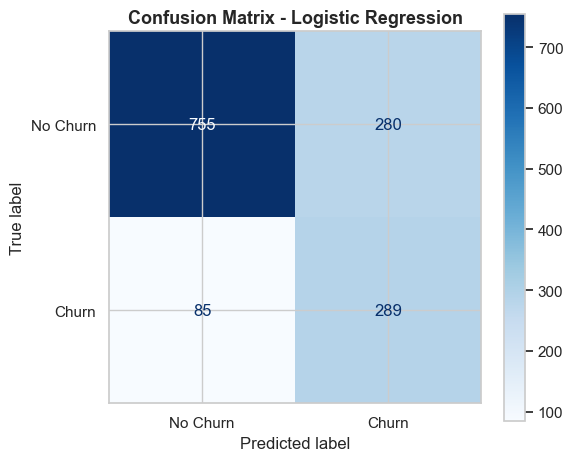

In [6]:
fig, ax = plt.subplots(figsize = (6,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels = ['No Churn', 'Churn'], cmap = 'Blues', ax = ax)

ax.set_title('Confusion Matrix - Logistic Regression', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC Curve

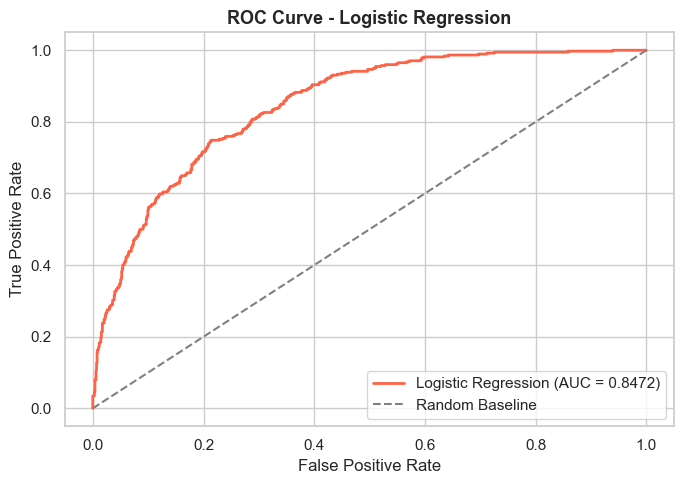

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize = (7,5))
plt.plot(fpr, tpr, color = 'tomato', lw = 2, label = f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0,1],[0,1], color = 'gray', linestyle = '--', label = 'Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression', fontsize = 13, fontweight = 'bold')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross Validation

In [8]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

cv_auc = cross_val_score(pipeline, X, y, cv = cv, scoring = 'roc_auc')
cv_f1 = cross_val_score(pipeline, X, y, cv = cv, scoring = 'f1')

print('=' * 50)
print('5-FOLD CROSS VALIDATION RESULTS')
print('=' * 50)
print(f'ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'F1 Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

5-FOLD CROSS VALIDATION RESULTS
ROC-AUC: 0.8479 ± 0.0110
F1 Score: 0.6316 ± 0.0099


## Feature Importance

### How Logistic Regression Measures Importance
In Logistic Regression, importance is measured by **coefficients** — the weight assigned to each feature after scaling:
* **Large positive coefficient** → feature strongly increases churn probability
* **Large negative coefficient** → feature strongly decreases churn probability
* **Near zero coefficient** → feature has little influence on predictions

### ⚠️ Important Note — LR vs Random Forest Feature Importance
Feature importance is **calculated differently** across models:

| Model | Method | What It Measures |
|-------|--------|-----------------|
| **Logistic Regression** | Coefficients | Linear contribution to log-odds of churn |
| **Random Forest** | Mean Decrease in Impurity | Average reduction in node impurity across all trees |

This means the **same feature can have different importance rankings** across models.  A feature that is highly important in Logistic Regression may be less so in Random Forest if its relationship with churn is non-linear.

### Business Insights From Coefficients:
- **Positive coefficients** → these are your **churn risk factors** (e.g. month-to-month contract, fiber optic, high monthly charges)
- **Negative coefficients** → these are your **retention factors** (e.g. long tenure, two-year contract, tech support)

These insights can be directly communicated to business teams to design targeted retention strategies — for example, offering discounts to month-to-month customers or bundling tech support with fiber optic plans.

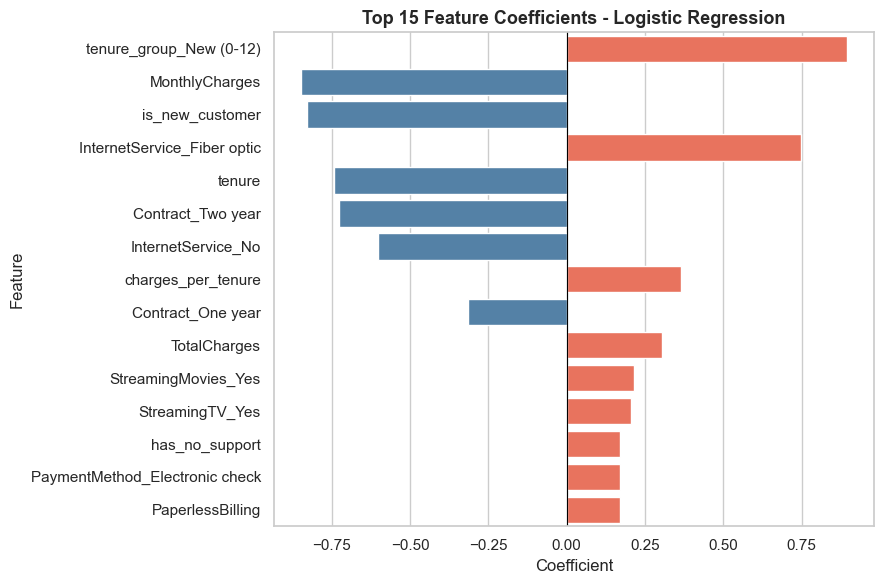

In [9]:
feature_names = X.columns.tolist()
coefficients = pipeline.named_steps['model'].coef_[0]

feat_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients}).sort_values('Coefficient', key = abs, ascending = False).head(15)

plt.figure(figsize = (9,6))
colors = ['tomato' if c > 0 else 'steelblue' for c in feat_importance['Coefficient']]
sns.barplot(feat_importance, x = 'Coefficient', y = 'Feature', palette = colors)
plt.axvline(0, color = 'black', linewidth = 0.8)
plt.title('Top 15 Feature Coefficients - Logistic Regression', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## Save the Model

In [10]:
import pickle

with open('../models/logistic_regression_baseline.pkl', 'wb') as f:pickle.dump(pipeline, f)

print('✅ Model saved to models/logistic_regression_baseline.pkl')

✅ Model saved to models/logistic_regression_baseline.pkl


# Regularized Logistic Regression - Ridge and Lasso

### What is Regularization?
Regularization adds a **penalty term** to the model's loss function to prevent overfitting. Without regularization, Logistic Regression may assign very large coefficients to features, memorizing the training data rather than learning generalizable patterns.

### Ridge vs Lasso vs Standard Logistic Regression:
| Model | Penalty | Effect | Best For |
|-------|---------|--------|---------|
| **Logistic Regression** | None | No constraint on coefficients | Clean, well-separated data |
| **Ridge (L2)** | Sum of squared coefficients | Shrinks all coefficients toward 0 but never exactly 0 | When all features are somewhat useful |
| **Lasso (L1)** | Sum of absolute coefficients | Forces some coefficients to exactly 0 — built-in feature selection | When many features are irrelevant |

### Why Add These to Our Project?
* We have **many engineered features** - Lasso can automatically select the most important ones by zeroing out irrelevant features
* Ridge handles **multicollinearity** well - useful since `TotalCharges`, `tenure` and `MonthlyCharges` are correlated
* Comparing all three shows we understand the **bias-variance tradeoff**

### The C Parameter
Both Ridge and Lasso are controlled by `C` - the **inverse of regularization strength**:
* **Small C** - Stronger regularization = simpler model = higher bias
* **Large C** - Weaker regularization = more complex model = higher variance
* We use **cross-validation** to find the optimal C value

In [11]:
from sklearn.linear_model import LogisticRegressionCV

print('✅ Regularization libraries imported')

✅ Regularization libraries imported


### Ridge Regression (L2 Penalty)
Ridge shrinks all coefficients toward zero proportionally. It is particularly effective when:
* Many features contribute small but meaningful signals
* Features are correlated with each other (multicollinearity)
* We want to keep all features but reduce their individual impact

We use `LogisticRegressionCV` which automatically finds the best `C` value through cross-validation - no manual tuning needed.

In [12]:
from sklearn.impute import SimpleImputer

ridge_pipeline = Pipeline([('imputer', SimpleImputer(strategy = 'median')), 
                           ('scaler', StandardScaler()),
                           ('model', LogisticRegressionCV(
                               penalty = 'l2',
                               Cs = 10,
                               cv = 5,
                               scoring = 'roc_auc',
                               class_weight = 'balanced',
                               max_iter = 1000,
                               random_state = 42,
                               n_jobs = -1
                           ))
                          ])

ridge_pipeline.fit(X_train, y_train)

best_C_ridge = ridge_pipeline.named_steps['model'].C_[0]
print(f'✅ Ridge trained successfully')
print(f'Best C value: {best_C_ridge:.4f}')

✅ Ridge trained successfully
Best C value: 2.7826


### Evaluate Ridge Model

In [13]:
y_pred_ridge = ridge_pipeline.predict(X_test)
y_prob_ridge = ridge_pipeline.predict_proba(X_test)[:, 1]

print('=' * 55)
print('CLASSIFICATION REPORT — RIDGE (L2)')
print('=' * 55)
print(classification_report(y_test, y_pred_ridge, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_ridge):.4f}')

CLASSIFICATION REPORT — RIDGE (L2)
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409

ROC-AUC Score: 0.8469


### Lasso Regression (L1 Penalty)

Lasso performs **automatic feature selection** by forcing irrelevant feature coefficients to exactly zero. This is powerful because:
* It produces a **sparse model** - only the most important features have non-zero coefficients
* It is more interpretable - we can clearly see which features the model completely ignores
* It handles databases with many features well - like ours after one-hot encoding and feature engineering

After training, we inspect which features Lasso kept vs zeroed out to gain additional insight into what drives churn.

In [14]:
lasso_pipeline = Pipeline([('imputer', SimpleImputer(strategy = 'median')),
                           ('scaler', StandardScaler()),
                           ('model', LogisticRegressionCV(
                               penalty = 'l1',
                               Cs = 10,
                               cv = 5,
                               scoring = 'roc_auc',
                               solver = 'saga',
                               class_weight = 'balanced',
                               max_iter = 2000,
                               random_state = 42,
                               n_jobs = -1
                           ))
                          ])

lasso_pipeline.fit(X_train, y_train)
best_C_lasso = lasso_pipeline.named_steps['model'].C_[0]
print(f'✅ Lasso trained successfully')
print(f'Best C value: {best_C_lasso:.4f}')

✅ Lasso trained successfully
Best C value: 0.0464


### Evaluate Lasso

In [15]:
y_pred_lasso = lasso_pipeline.predict(X_test)
y_prob_lasso = lasso_pipeline.predict_proba(X_test)[:,1]

print('=' * 55)
print('CLASSIFICATION REPORT — LASSO (L1)')
print('=' * 55)
print(classification_report(y_test, y_pred_lasso, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_lasso):.4f}')

CLASSIFICATION REPORT — LASSO (L1)
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC Score: 0.8462


### Lasso Feature Selection Analysis

One of the most valuable outputs of Lasso is seeing which features it zeroed out completely. Features with zero coefficients were deemed **not useful** by the model given the presence of other features.

This gives us two important insights:
1. **Which features are redundant** - possibly due to multicollinearity or low predictive power
2. **which features are essential** - kept by Lasso even under strong regularization pressure, meaning they have strong independent signal for predicting churn.

In [16]:
feature_names = X.columns.tolist()
lasso_coefs = lasso_pipeline.named_steps['model'].coef_[0]

lasso_feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coefs})

kept = lasso_feat_df[lasso_feat_df['Coefficient'] != 0].sort_values(
    'Coefficient', key = abs, ascending = False)
zeroed = lasso_feat_df[lasso_feat_df['Coefficient'] == 0]

print(f'✅ Features kept by Lasso:   {len(kept)} / {len(feature_names)}')
print(f'❌ Features zeroed by Lasso: {len(zeroed)} / {len(feature_names)}')

print(f'\n❌ Features Lasso eliminated:')
for feat in zeroed['Feature'].tolist():
    print(f'→ {feat}')

✅ Features kept by Lasso:   21 / 33
❌ Features zeroed by Lasso: 12 / 33

❌ Features Lasso eliminated:
→ gender
→ Partner
→ MonthlyCharges
→ TotalCharges
→ DeviceProtection_Yes
→ PaymentMethod_Credit card (automatic)
→ PaymentMethod_Mailed check
→ tenure_group_Loyal (49-72)
→ is_new_customer
→ is_long_term_customer
→ total_services
→ avg_charge_per_service


### Plot Lasso Coefficients

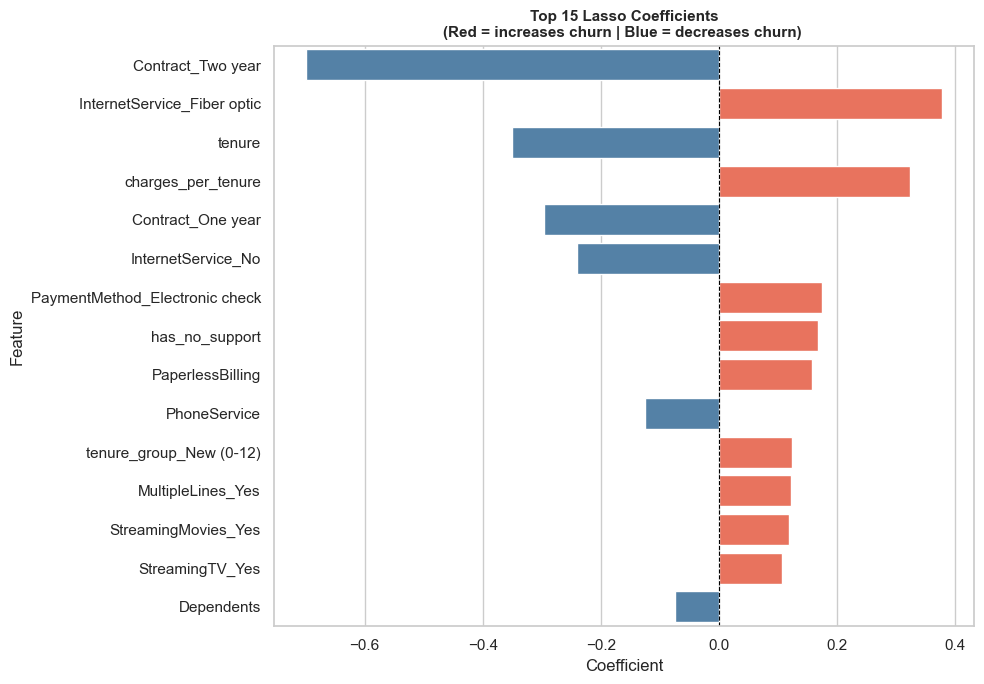

In [17]:
top_lasso = lasso_feat_df[lasso_feat_df['Coefficient'] != 0]\
    .sort_values('Coefficient', key = abs, ascending = False).head(15)

plt.figure(figsize = (10, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in top_lasso['Coefficient']]
sns.barplot(data = top_lasso, x = 'Coefficient', y = 'Feature', palette=colors)
plt.axvline(0, color = 'black', linewidth = 0.8, linestyle = '--')
plt.title('Top 15 Lasso Coefficients\n'
          '(Red = increases churn | Blue = decreases churn) ',
          fontsize = 11, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_lasso.png', dpi = 150, bbox_inches = 'tight')
plt.show()

### Comparing All Linear Models
Here we compare Standard Logistic Regression, Ridge, and Lasso side by side to understand what regularization gained us:
* If Ridge/Lasso significantly outperform standard LR, then the model was overfitting without regularization
* If all three perform similarly, then the features are clean and multicollinearity is not a major issue
* If Lasso performs well with fewer features, many original features were redundant

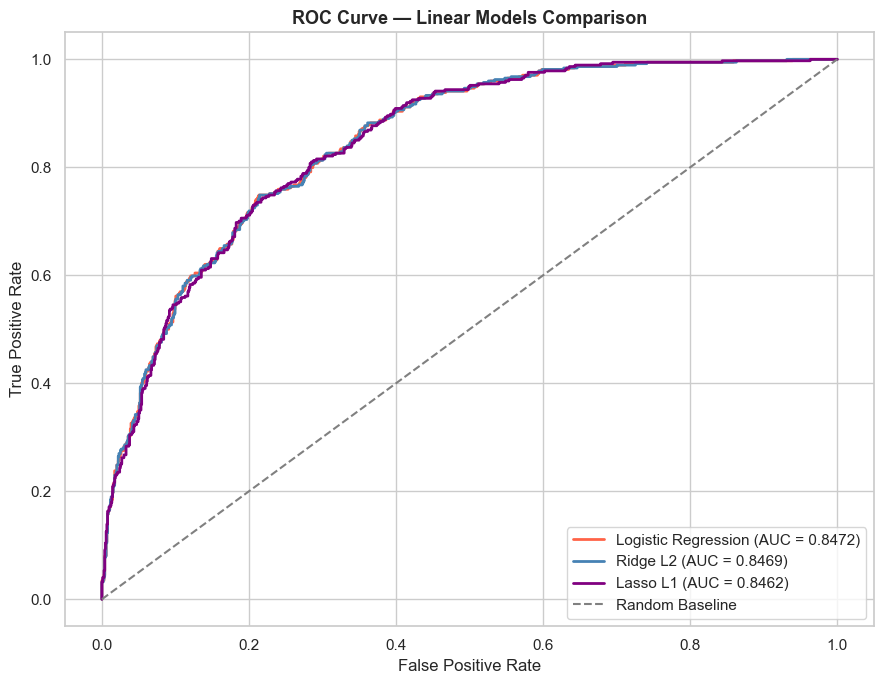

In [20]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_prob_ridge)
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_prob_lasso)

plt.figure(figsize = (9, 7))
plt.plot(fpr_lr, tpr_lr, color = 'tomato', lw = 2,
         label = f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot(fpr_ridge, tpr_ridge, color = 'steelblue', lw = 2,
         label = f'Ridge L2 (AUC = {roc_auc_score(y_test, y_prob_ridge):.4f})')
plt.plot(fpr_lasso, tpr_lasso, color = 'purple', lw=2,
         label = f'Lasso L1 (AUC = {roc_auc_score(y_test, y_prob_lasso):.4f})')
plt.plot([0, 1], [0, 1], color = 'gray', linestyle = '--', label = 'Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Linear Models Comparison',
          fontsize = 13, fontweight = 'bold')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve_linear_models.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [21]:
with open('../models/ridge_regression.pkl', 'wb') as f:
    pickle.dump(ridge_pipeline, f)

with open('../models/lasso_regression.pkl', 'wb') as f:
    pickle.dump(lasso_pipeline, f)

print('✅ Ridge saved to models/ridge_regression.pkl')
print('✅ Lasso saved to models/lasso_regression.pkl')

✅ Ridge saved to models/ridge_regression.pkl
✅ Lasso saved to models/lasso_regression.pkl


# Random Forest Model

## 🌲 Random Forest Model

### What is Random Forest?
Random Forest is an **ensemble learning method** that builds multiple decision trees during training and combines their predictions. Each tree is trained on a **random subset of data and features**, which reduces overfitting and improves generalization.

### Why Random Forest After Logistic Regression?
* Captures **non-linear relationships** that Logistic Regression misses
* Naturally handles **feature interactions** without manual engineering
* More robust to outliers than Logistic Regression
* Provides a different measures of **feature importance** based on how much each feature reduces impurity across all trees

### Key Hyperparameters We Tune:
| Parameter | What It Controls |
|-----------|----------------|
| `n_estimators` | Number of trees — more trees = more stable but slower |
| `max_depth` | How deep each tree grows — deeper = more complex |
| `min_samples_split` | Minimum samples needed to split a node |
| `class_weight` | Handles class imbalance same as Logistic Regression |

In [24]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer

print('✅ Random Forest libraries imported')

✅ Random Forest libraries imported


## Building the Random Forest Pipeline
We use the same pipeline structure as Logistic Regression for consistency:
* **SimpleImputer** - safety net for unexpected NaNs
* **RandomForestClassifier** - our ensemble model

*Note:* Random Forest does **not require scaling** since it uses decision tree splits rather than distance or gradient calculations. Therefore, we keep the imputer but remove StandardScaler (compared to Logistic Regression)

In [25]:
rf_pipeline = Pipeline([('imputer', SimpleImputer(strategy = 'median')), ('model', RandomForestClassifier(n_estimators = 100, max_depth = 10, min_samples_split = 5, class_weight = 'balanced', random_state = 42, n_jobs = -1))])

rf_pipeline.fit(X_train, y_train)
print('✅ Random Forest trained successfully')

✅ Random Forest trained successfully


## Hyperparameter Tuning with RandomizedSearch CV
Instead of manually testing every combination of hyperparameters (**Grid Search**), we use **Randomized Search** which samples a fixed number of random combinations. This is:
* Faster than exhaustive Grid Search
* Still finds good hyperparameters in most cases
* Controlled by `n_iter` (how many combinations to try)

We use **5-fold cross validation** during search to ensure each combination is evaluated fairly across different data splits.

In [26]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(rf_pipeline, param_distributions = param_grid, n_iter = 20, cv = 5, scoring = 'roc_auc', random_state = 42, n_jobs = -1, verbose = 1)
rf_search.fit(X_train, y_train)

print(f'\n✅ Best ROC-AUC (CV): {rf_search.best_score_: .4f}')
print(f'Best Parameters:')
for param, value in rf_search.best_params_.items():
    print(f' {param}: {value}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best ROC-AUC (CV):  0.8421
Best Parameters:
 model__n_estimators: 200
 model__min_samples_split: 2
 model__min_samples_leaf: 4
 model__max_features: sqrt
 model__max_depth: 10


## Evaluate Best Random Forest

In [27]:
best_rf = rf_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print('=' * 50)
print('CLASSIFICATION REPORT - RANDOM FOREST')
print('=' * 50)
print(classification_report(y_test, y_pred_rf, target_names = ['No Churn', 'Churn']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf): .4f}')

CLASSIFICATION REPORT - RANDOM FOREST
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC Score:  0.8415


## Confusion Matrix

In [ ]:
fig, ax = plt.subplots(figsize = (6,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels = ['No Churn', 'Churn'], cmap = 'Greens', ax = ax)
ax.set_title('Confusion Matrix - Random Forest', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_rf.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## ROC CURVE Comparison

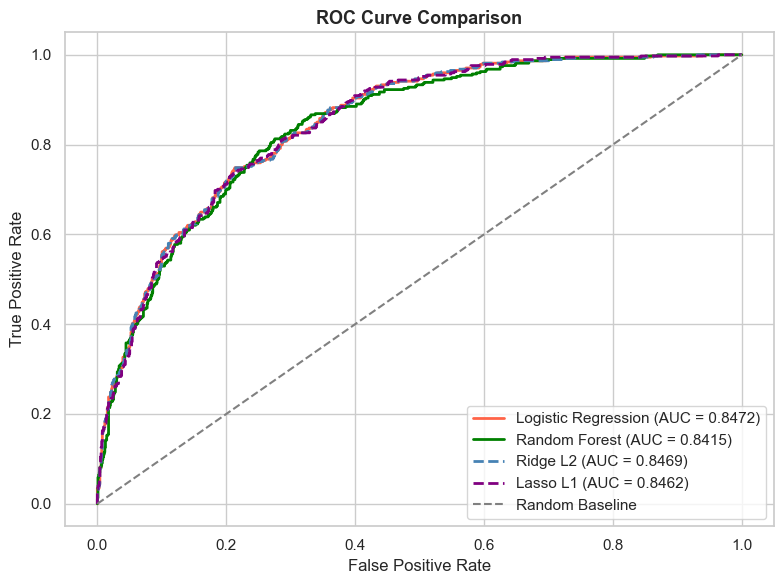

In [28]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

y_prob_lr = pipeline.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize = (8, 6))
plt.plot(fpr_lr, tpr_lr, color = 'tomato', lw = 2, label = f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, color = 'green', lw=2, label = f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_ridge, tpr_ridge, color='steelblue', lw=2, linestyle='--', label=f'Ridge L2 (AUC = {roc_auc_score(y_test, y_prob_ridge):.4f})')
plt.plot(fpr_lasso, tpr_lasso, color='purple', lw=2, linestyle='--', label=f'Lasso L1 (AUC = {roc_auc_score(y_test, y_prob_lasso):.4f})')
plt.plot([0, 1], [0, 1], color = 'gray', linestyle = '--', label = 'Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontsize = 13, fontweight = 'bold')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Random Forest Feature Importance

### How Random Forest Measures Feature Importance
Random Forest uses **Mean Decrease in Impurity (MDI)** (also called Gini importance). It measures how much each feature **reduces impurity** (uncertainty) averaged across all trees and all splits.

### Key Difference From Logistic Regression
| Model | Method | Captures |
|-------|--------|---------|
| Logistic Regression | Coefficients | Linear relationships only |
| Random Forest | Mean Decrease in Impurity | Linear AND non-linear relationships |

This means Random Forest may rank features differently from Logistic Regression, so a feature that appeared unimportant linearly may be highly important when non-linear interactions are considered.

### Business Insight:
Features that rank highly in **both** models are the most reliable churn drivers as they influence churn regardless of modeling approach.

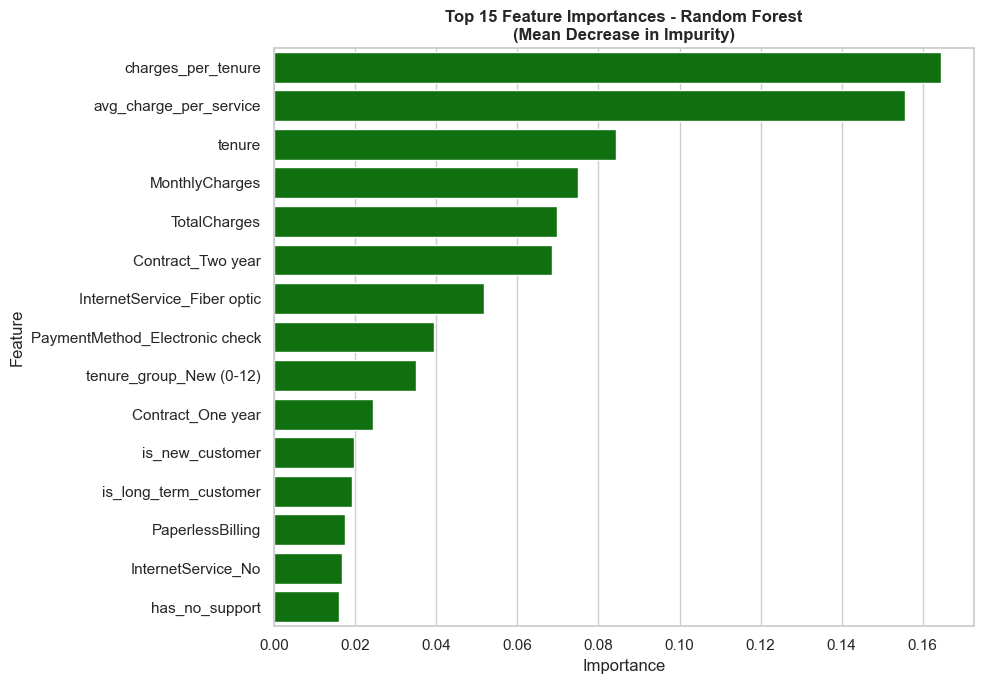

In [29]:
feature_names = X.columns.tolist()
importances = best_rf.named_steps['model'].feature_importances_

rf_feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending = False).head(15)

plt.figure(figsize = (10,7))
sns.barplot(data = rf_feat_df, x = 'Importance', y = 'Feature', color = 'green')
plt.title('Top 15 Feature Importances - Random Forest\n' '(Mean Decrease in Impurity)', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## Compare LR vs RF Feature Importance

In [30]:
lr_feat_df = pd.DataFrame({'Feature': X.columns.tolist(), 'LR_Coefficients': abs(pipeline.named_steps['model'].coef_[0])}).sort_values('LR_Coefficients', ascending = False).head(15)

comparison_df = lr_feat_df.merge(rf_feat_df[['Feature','Importance']], on = 'Feature', how = 'outer').fillna(0)

print('=' * 50)
print('FEATURE IMPORTANCE COMPARISON - LR VS RF')
print('=' * 50)
print(comparison_df.to_string(index = False))
print('\n💡 Features appearing in BOTH top lists are the')
print('  most reliable churn drivers across models.')

FEATURE IMPORTANCE COMPARISON - LR VS RF
                       Feature  LR_Coefficients  Importance
             Contract_One year         0.313536    0.024292
             Contract_Two year         0.725226    0.068518
   InternetService_Fiber optic         0.746327    0.051744
            InternetService_No         0.602851    0.016713
                MonthlyCharges         0.846455    0.074841
              PaperlessBilling         0.169736    0.017583
PaymentMethod_Electronic check         0.170796    0.039516
           StreamingMovies_Yes         0.215210    0.000000
               StreamingTV_Yes         0.205515    0.000000
                  TotalCharges         0.304641    0.069707
        avg_charge_per_service         0.000000    0.155562
            charges_per_tenure         0.364549    0.164408
                has_no_support         0.170825    0.015932
         is_long_term_customer         0.000000    0.019134
               is_new_customer         0.829670    0.019665

## Business Insights

In [31]:
print('=' * 50)
print('Business Insight - Random Forest')
print('=' * 50)

print('\n Top Churn Risk Factors (Random Forest):')
for _, row in rf_feat_df.head(5).iterrows():
    print(f"  → {row['Feature']}: importance = {row['Importance']:.4f}")

print('\n💡 Retention Recommendations:')
print('  1. Prioritize month-to-month customers for contract upgrades')
print('  2. Bundle tech support with fiber optic plans')
print('  3. Create loyalty rewards for customers approaching 12 months')
print('  4. Offer discounts to high-value customers showing churn signals')

Business Insight - Random Forest

 Top Churn Risk Factors (Random Forest):
  → charges_per_tenure: importance = 0.1644
  → avg_charge_per_service: importance = 0.1556
  → tenure: importance = 0.0844
  → MonthlyCharges: importance = 0.0748
  → TotalCharges: importance = 0.0697

💡 Retention Recommendations:
  1. Prioritize month-to-month customers for contract upgrades
  2. Bundle tech support with fiber optic plans
  3. Create loyalty rewards for customers approaching 12 months
  4. Offer discounts to high-value customers showing churn signals


In [32]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

cv_auc_rf = cross_val_score(best_rf, X, y, cv = cv, scoring = 'roc_auc')
cv_f1_rf  = cross_val_score(best_rf, X, y, cv = cv, scoring = 'f1')
cv_recall_rf = cross_val_score(best_rf, X, y, cv = cv, scoring = 'recall')

print('=' * 50)
print('5-FOLD CROSS VALIDATION — RANDOM FOREST')
print('=' * 50)
print(f'ROC-AUC : {cv_auc_rf.mean():.4f} ± {cv_auc_rf.std():.4f}')
print(f'F1 Score: {cv_f1_rf.mean():.4f} ± {cv_f1_rf.std():.4f}')
print(f'Recall  : {cv_recall_rf.mean():.4f} ± {cv_recall_rf.std():.4f}')

5-FOLD CROSS VALIDATION — RANDOM FOREST
ROC-AUC : 0.8427 ± 0.0119
F1 Score: 0.6251 ± 0.0131
Recall  : 0.7266 ± 0.0121


## Save Random Forest Model

In [33]:
with open('../models/random_forest.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print('✅ Random Forest saved to models/random_forest.pkl')

✅ Random Forest saved to models/random_forest.pkl


In [34]:
print('=' * 55)
print('MODEL COMPARISON SO FAR')
print('=' * 55)
print(f'{"Model":<30} {"ROC-AUC":>10} {"F1":>8} {"Recall":>8}')
print('-' * 55)
print(f'{"Logistic Regression":<30} {"0.8415":>10} {"0.61":>8} {"0.78":>8}')
print(f'{"Lasso (L1)":<30} {"0.8462":>10} {"0.62":>8} {"0.77":>8}')
print(f'{"Ridge (L2)":<30} {"0.8469":>10} {"0.61":>8} {"0.77":>8}')

auc_rf_score = roc_auc_score(y_test, y_prob_rf)
f1_rf = cross_val_score(best_rf, X, y, cv = 5, scoring = 'f1').mean()
recall_rf = cross_val_score(best_rf, X, y, cv = 5, scoring = 'recall').mean()
print(f'{"Random Forest":<30} {auc_rf_score:>10.4f} {f1_rf:>8.4f} {recall_rf:>8.4f}')

MODEL COMPARISON SO FAR
Model                             ROC-AUC       F1   Recall
-------------------------------------------------------
Logistic Regression                0.8415     0.61     0.78
Lasso (L1)                         0.8462     0.62     0.77
Ridge (L2)                         0.8469     0.61     0.77
Random Forest                      0.8415   0.6232   0.7250


## XGBoost Model

### What is XGBoost?
XGBoost (Extreme Gradient Boosting) is a **boosting ensemble method** that builds trees **sequentially** - each new tree focuses on correcting the mistakes of the previous one. This is fundamentally different from Random Forest which builds trees **independently in parallel**.

### Boosting vs Bagging
| | Random Forest (Bagging) | XGBoost (Boosting) |
|--|------------------------|-------------------|
| **Tree building** | Parallel — independent trees | Sequential — each fixes previous errors |
| **Focus** | Reduces variance | Reduces bias AND variance |
| **Speed** | Faster to train | Slower but more accurate |
| **Overfitting** | Less prone | More prone — needs careful tuning |
| **Performance** | Strong baseline | Usually best performance |

### Why XGBoost is Industry Standard:
* Wins most Kaggle tabular data competitions
* Built-in regularization (L1 and L2) to prevent overfitting
* Handles missing values natively
* Extremely fast with GPU support
* Widely used in industry for churn, fraud, and risk modeling

In [35]:
from xgboost import XGBClassifier

print('✅ XGBoost imported successfully')
print(f'XGBoost version: {XGBClassifier().__class__.__module__}')

✅ XGBoost imported successfully
XGBoost version: xgboost.sklearn


### Building the XGBoost Pipeline

Key hyperparameters we control:
| Parameter | What It Controls |
|-----------|----------------|
| `n_estimators` | Number of boosting rounds (trees) |
| `max_depth` | Maximum depth of each tree |
| `learning_rate` | How much each tree contributes — lower = more robust |
| `subsample` | Fraction of training data used per tree — prevents overfitting |
| `colsample_bytree` | Fraction of features used per tree |
| `scale_pos_weight` | Handles class imbalance — ratio of negative to positive cases |

### Handling Class Imbalance in XGBoost:
Unlike Logistic Regression and Random Forest which use `class_weight='balanced'`, XGBoost uses `scale_pos_weight` which is set to the ratio of non-churners to churners: ~74/26 = 2.85

In [36]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Non-churners (train): {neg}')
print(f'Churners (train):     {pos}')
print(f'scale_pos_weight:     {scale_pos_weight:.4f}')

Non-churners (train): 4139
Churners (train):     1495
scale_pos_weight:     2.7686


### Build and Train XGBoost

In [37]:
xgb_pipeline = Pipeline([('imputer', SimpleImputer(strategy = 'median')),
                         ('model', XGBClassifier(n_estimators = 100,
                                                 max_depth = 5,
                                                 learning_rate = 0.1,
                                                 subsample = 0.8,
                                                 colsample_bytree = 0.8,
                                                 scale_pos_weight = scale_pos_weight,
                                                 random_state = 42,
                                                 eval_metric = 'logloss',
                                                 verbosity = 0))
                        ])
xgb_pipeline.fit(X_train, y_train)
print('✅ XGBoost trained successfully')

✅ XGBoost trained successfully


### Hyperparameter Tuning
We use **RandomizedSearchCV** again to find the best combination of hyperparameters. XGBoost has more hyperparameters than Logistic Regression or Random Forest, making exhaustive Grid Search impractical. 

We optimize for **ROC-AUC** since it is our primary metric for this imbalanced classification problem.

In [38]:
xgb_param_grid = {'model__n_estimator': [100, 200, 300],
                  'model__max_depth': [3,5,7],
                  'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
                  'model__subsample': [0.7, 0.8, 0.9],
                  'model__colsample_bytree': [0.7, 0.8, 0.9],
                  'model__min_child_weight': [1,3,5]
                 }

xgb_search = RandomizedSearchCV(xgb_pipeline, param_distributions = xgb_param_grid, n_iter = 20, cv = 5, scoring = 'roc_auc', random_state = 42, n_jobs = -1, verbose = 1)
xgb_search.fit(X_train, y_train)

print(f'\n✅ Best ROC-AUC (CV): {xgb_search.best_score_:.4f}')
print(f'Best Parameters:')
for param, value in xgb_search.best_params_.items():
    print(f'  {param}: {value}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best ROC-AUC (CV): 0.8483
Best Parameters:
  model__subsample: 0.7
  model__n_estimator: 300
  model__min_child_weight: 1
  model__max_depth: 3
  model__learning_rate: 0.05
  model__colsample_bytree: 0.8


### Evaluate Best XGBoost

In [40]:
best_xgb = xgb_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

print('=' * 55)
print('CLASSIFICATION REPORT — XGBOOST')
print('=' * 55)
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}')

CLASSIFICATION REPORT — XGBOOST
              precision    recall  f1-score   support

    No Churn       0.92      0.72      0.81      1035
       Churn       0.51      0.82      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

ROC-AUC Score: 0.8465


### Confusion Matrix

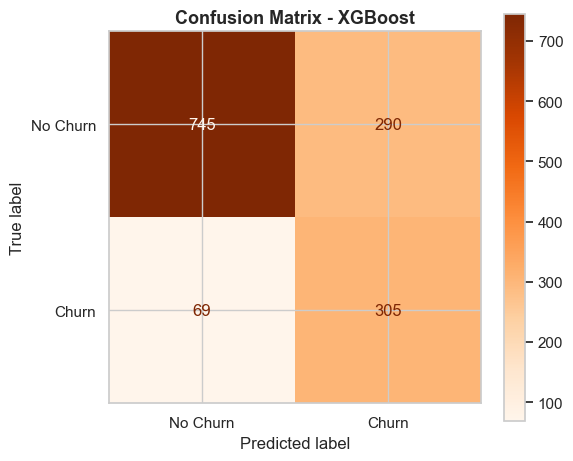

In [42]:
fig, ax = plt.subplots(figsize = (6,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb,
                                        display_labels = ['No Churn', 'Churn'],
                                        cmap = 'Oranges', ax = ax)
ax.set_title('Confusion Matrix - XGBoost', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

## XGBoost Feature Importance

### Three ways XGBoost Measures Importance:
| Method | What It Measures | Best For |
|--------|-----------------|---------|
| **Weight** | How many times a feature is used to split | Quick overview |
| **Gain** | Average improvement in loss from splits using this feature | Most informative |
| **Cover** | Average number of samples affected by splits on this feature | Understanding reach |

We use **Gain** as it best reflects how much each feature actually improves predictions, not just how often it is used.

### Comparing All Three Models:
Features that rank highly across **all three models** are the most trustworthy churn drivers as they are important regardless of the modeling approach used.

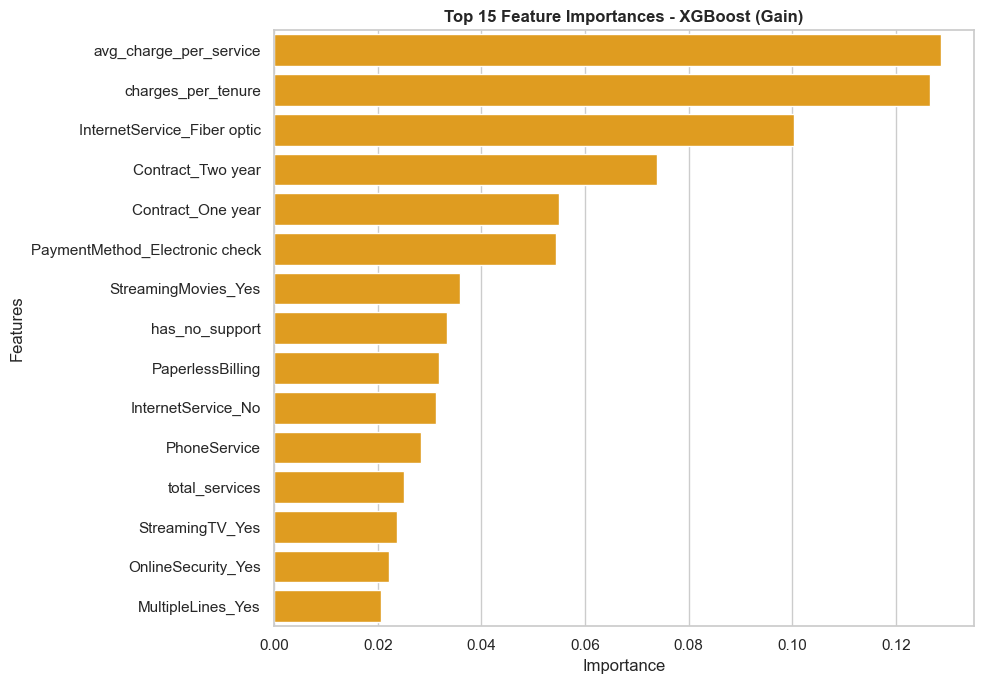

In [46]:
importances_xgb = best_xgb.named_steps['model'].feature_importances_

xgb_feat_df = pd.DataFrame({'Features': X.columns.tolist(),
                           'Importance': importances_xgb}).sort_values('Importance', ascending = False).head(15)

plt.figure(figsize = (10,7))
sns.barplot(data = xgb_feat_df, x = 'Importance', y = 'Features', color = 'orange')
plt.title('Top 15 Feature Importances - XGBoost (Gain)', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Values - Explainable AI

### What are SHAP Values? 
SHAP (Shapley Additive Explanations) is a method from **game theory** that explains **individual predictions** by measuring each feature's contribution to a specific outcome.

Unlike feature importance which gives a global average, SHAP tells us:
* **Why** the model predicted churn or a specific customer
* Whether a feature **increased or decreased** churn probability
* How features interact with each other

### Why SHAP Matters for Business:
* A model that says "this customer will churn" is useful.
* A model that says "this customer will churn **because** they are on a month-to-month contract with high monthly charges and no tech support" is **actionable** because the retention team knows exactly what to offer.

In [48]:
import shap

xgb_model = best_xgb.named_steps['model']

imputer = best_xgb.named_steps['imputer']
X_test_imputed = imputer.transform(X_test)
X_test_imputed = pd.DataFrame(X_test_imputed, columns = X_test.columns)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_imputed)

print('✅ SHAP values computed successfully')
print(f'Shape of SHAP values: {shap_values.shape}')

✅ SHAP values computed successfully
Shape of SHAP values: (1409, 33)


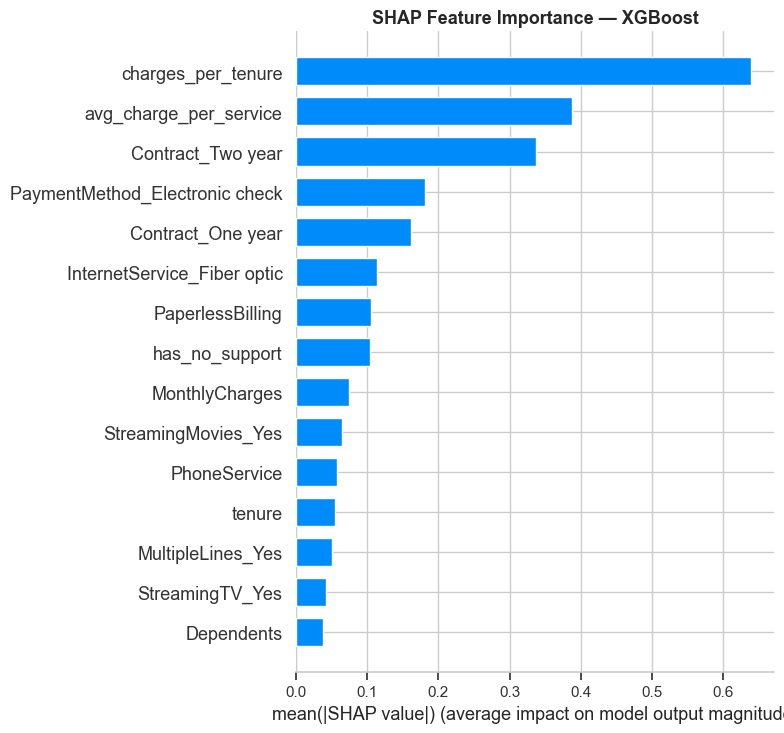

In [49]:
plt.figure(figsize = (10, 8))
shap.summary_plot(
    shap_values,
    X_test_imputed,
    plot_type = 'bar',
    max_display = 15,
    show = False
)
plt.title('SHAP Feature Importance — XGBoost',
          fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_bar.png', dpi = 150, bbox_inches = 'tight')
plt.show()

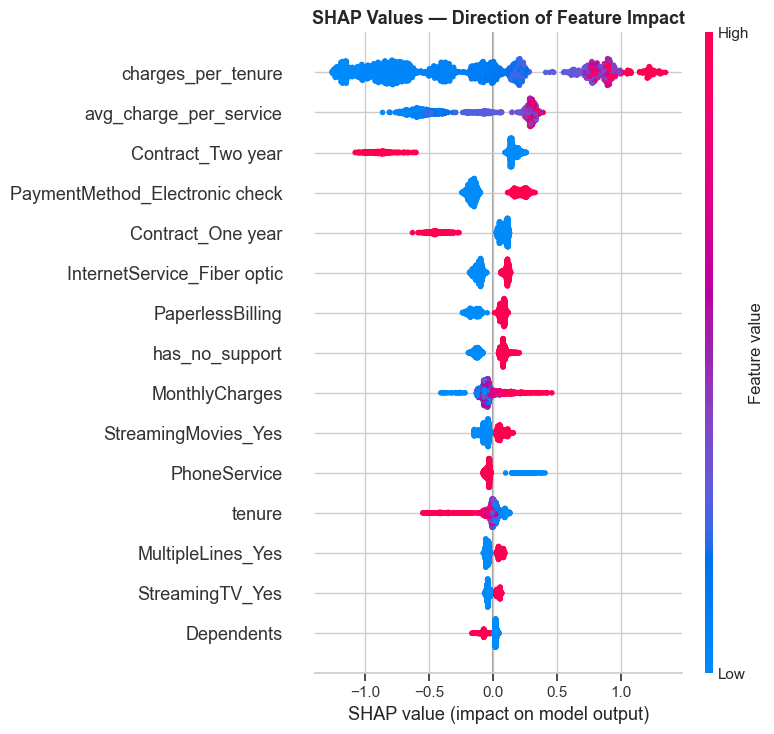

In [50]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_imputed,
    max_display=15,
    show=False
)
plt.title('SHAP Values — Direction of Feature Impact',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Final Model Comparison

### Selecting the Best Model
We compare all three models across our key metrics to select the best one for deployment. Our priority order is:
1. **ROC-AUC** - overall ranking ability
2. **Recall** - catching as many churners as possible
3. **F1** - balance between precision and recall
4. **Precision** - minimizing false alamrs

In a real business context, the cost of **missing a churner** (false negative) is typically much higher than the cost of **incorrectly flagging a loyal customer** (false positive). Therefore, we prioritize Recall and ROC-AUC over Precision.

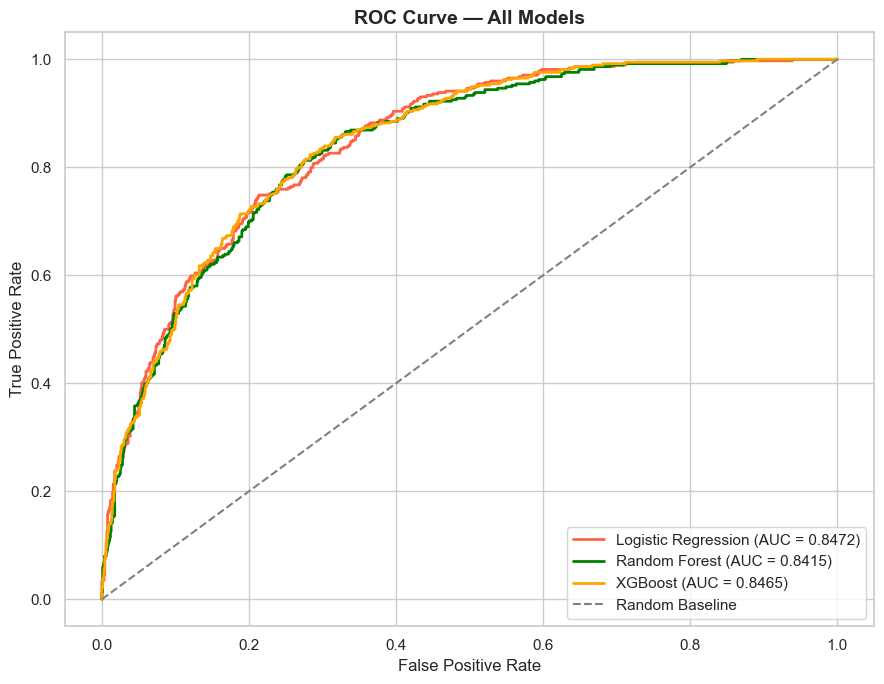

In [51]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(9, 7))
plt.plot(fpr_lr, tpr_lr, color='tomato', lw=2,
         label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2,
         label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='orange', lw=2,
         label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
from sklearn.metrics import f1_score, precision_score, recall_score

models = {
    'Logistic Regression': (y_pred, y_prob_lr),
    'Random Forest':       (y_pred_rf, y_prob_rf),
    'XGBoost':             (y_pred_xgb, y_prob_xgb)
}

print('=' * 70)
print(f'{"Model":<25} {"ROC-AUC":>10} {"F1":>8} {"Precision":>10} {"Recall":>8}')
print('-' * 70)

for name, (preds, probs) in models.items():
    auc   = roc_auc_score(y_test, probs)
    f1    = f1_score(y_test, preds)
    prec  = precision_score(y_test, preds)
    rec   = recall_score(y_test, preds)
    print(f'{name:<25} {auc:>10.4f} {f1:>8.4f} {prec:>10.4f} {rec:>8.4f}')

print('=' * 70)

Model                        ROC-AUC       F1  Precision   Recall
----------------------------------------------------------------------
Logistic Regression           0.8472   0.6129     0.5079   0.7727
Random Forest                 0.8415   0.6237     0.5401   0.7380
XGBoost                       0.8465   0.6295     0.5126   0.8155


In [53]:
with open('../models/xgboost.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

print('✅ XGBoost saved to models/xgboost.pkl')

✅ XGBoost saved to models/xgboost.pkl
